# Assignment #1

**Janin Jankovski, Florian Robrecht, Anna Hartmann**

---

## Datasets

**Dataset 1:** Kaggle Pokémon Dataset  
https://www.kaggle.com/datasets/rounakbanik/pokemon/  

**Dataset 2:** EuroSAT Land Use and Land Cover Satellite Dataset  
https://github.com/phelber/EuroSAT?utm_source=chatgpt.com

---

## Introduction

We use two datasets to highlight how dimensionality reduction behaves in different settings: a simpler tabular dataset (Pokémon) and a more complex image dataset (satellite data).

The Pokémon dataset consists of engineered features, such as type interactions and manually constructed attributes. These features do not naturally lie in a geometric space, meaning that Euclidean distances between data points are less meaningful. The task is to classify whether a Pokémon is legendary or not. Legendary Pokémon are rare, powerful entities within the Pokémon universe, typically unique, non-evolving, and associated with specific in-game events or lore.

In contrast, the european space agency satellite dataset consists of image-based data, where each observation is represented as pixel intensities. These features inherently form a geometric structure in Euclidean space, where distances between points reflect visual similarity. Therefore, dimensionality reduction techniques such as random projection are expected to better preserve meaningful structure in this setting.

In [21]:
# import general libraries
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt

# import sklearn libraries 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.random_projection import SparseRandomProjection, johnson_lindenstrauss_min_dim
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [22]:
# Shared helper functions for random projection experiments

def make_dims(max_dim, n_points=20):
    """Log-spaced dimensions: denser at low k, sparser at high k."""
    return np.unique(np.geomspace(2, max_dim, n_points).astype(int))


def run_rp_experiment(X_train, X_test, y_train, y_test, dims,
                      realizations=15, max_iter=2000, f1_avg='binary'):
    """Run sparse random projection + LinearSVC for each dimension,
    repeated over multiple realizations."""
    acc_all = np.zeros((realizations, len(dims)))
    f1_all  = np.zeros((realizations, len(dims)))

    for j, dim in enumerate(dims):
        for i in range(realizations):
            rp = SparseRandomProjection(n_components=dim, random_state=i)
            X_train_rp = rp.fit_transform(X_train)
            X_test_rp  = rp.transform(X_test)

            model = LinearSVC(max_iter=max_iter, random_state=42)
            model.fit(X_train_rp, y_train)
            y_pred = model.predict(X_test_rp)

            acc_all[i, j] = accuracy_score(y_test, y_pred)
            f1_all[i, j]  = f1_score(y_test, y_pred, average=f1_avg, zero_division=0)

        print(f"  k={dim:4d}:  acc = {acc_all[:, j].mean():.4f} +/- {acc_all[:, j].std():.4f}  |  "
              f"F1 = {f1_all[:, j].mean():.4f} +/- {f1_all[:, j].std():.4f}")

    return {
        'mean_acc': acc_all.mean(axis=0), 'std_acc': acc_all.std(axis=0),
        'mean_f1':  f1_all.mean(axis=0),  'std_f1':  f1_all.std(axis=0),
        'single_acc': acc_all[0],  # first realization for single-vs-ensemble plot
    }


def plot_rp_results(dims, results, baseline_acc, baseline_f1, title, realizations):
    """Standard 4-panel plot: accuracy, F1, variability, single vs. ensemble."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Accuracy
    axes[0, 0].plot(dims, results['mean_acc'], 'b-o', markersize=4, label='RP mean accuracy')
    axes[0, 0].fill_between(dims, results['mean_acc'] - results['std_acc'],
                            results['mean_acc'] + results['std_acc'], alpha=0.2)
    axes[0, 0].axhline(baseline_acc, color='r', linestyle='--', label=f'Baseline: {baseline_acc:.3f}')
    axes[0, 0].set(xlabel='Projected dimensions k', ylabel='Accuracy',
                   title=f'{title}: Accuracy vs. Dimension')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].legend()

    # F1-score
    axes[0, 1].plot(dims, results['mean_f1'], 'g-o', markersize=4, label='RP mean F1')
    axes[0, 1].fill_between(dims, results['mean_f1'] - results['std_f1'],
                            results['mean_f1'] + results['std_f1'], alpha=0.2, color='g')
    axes[0, 1].axhline(baseline_f1, color='r', linestyle='--', label=f'Baseline: {baseline_f1:.3f}')
    axes[0, 1].set(xlabel='Projected dimensions k', ylabel='F1-score',
                   title=f'{title}: F1-score vs. Dimension')
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].legend()

    # Variability
    axes[1, 0].plot(dims, results['std_acc'], 'b-o', markersize=4, label='Accuracy std')
    axes[1, 0].plot(dims, results['std_f1'], 'g-o', markersize=4, label='F1 std')
    axes[1, 0].set(xlabel='Projected dimensions k', ylabel='Standard deviation',
                   title=f'{title}: Metric Variability across Projections')
    axes[1, 0].legend()

    # Single vs. Ensemble
    axes[1, 1].plot(dims, results['single_acc'], 'c-', alpha=0.7, linewidth=1, label='Single realization')
    axes[1, 1].plot(dims, results['mean_acc'], 'b-', linewidth=2.5, label=f'Averaged ({realizations} runs)')
    axes[1, 1].fill_between(dims, results['mean_acc'] - results['std_acc'],
                            results['mean_acc'] + results['std_acc'], alpha=0.15, color='b')
    axes[1, 1].axhline(baseline_acc, color='r', linestyle='--', label=f'Baseline: {baseline_acc:.3f}')
    axes[1, 1].set(xlabel='Projected dimensions k', ylabel='Accuracy',
                   title=f'{title}: Single Run vs. Ensemble Average')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

## 1. Pokémon Dataset

In [23]:
# load pokemon dataset
path = kagglehub.dataset_download("rounakbanik/pokemon")
df = pd.read_csv(os.path.join(path, "pokemon.csv"))

In [24]:
# Exploratory Data Analysis (EDA)

# First look
pd.set_option('display.max_columns', None)
display(df.head())
pd.reset_option('display.max_columns')

# Check size 
display(df.shape)

# Columns
display(df.columns)

# Data types
display(df.info())

# Missing values in %
display((df.isna().sum() / len(df)) * 100)

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1.0,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2.0,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,NaN,19.0,1,0


(801, 41)

Index(['abilities', 'against_bug', 'against_dark', 'against_dragon',
       'against_electric', 'against_fairy', 'against_fight', 'against_fire',
       'against_flying', 'against_ghost', 'against_grass', 'against_ground',
       'against_ice', 'against_normal', 'against_poison', 'against_psychic',
       'against_rock', 'against_steel', 'against_water', 'attack',
       'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate',
       'classfication', 'defense', 'experience_growth', 'height_m', 'hp',
       'japanese_name', 'name', 'percentage_male', 'pokedex_number',
       'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg',
       'generation', 'is_legendary'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    str    
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non-null    fl

None

abilities             0.000000
against_bug           0.000000
against_dark          0.000000
against_dragon        0.000000
against_electric      0.000000
against_fairy         0.000000
against_fight         0.000000
against_fire          0.000000
against_flying        0.000000
against_ghost         0.000000
against_grass         0.000000
against_ground        0.000000
against_ice           0.000000
against_normal        0.000000
against_poison        0.000000
against_psychic       0.000000
against_rock          0.000000
against_steel         0.000000
against_water         0.000000
attack                0.000000
base_egg_steps        0.000000
base_happiness        0.000000
base_total            0.000000
capture_rate          0.000000
classfication         0.000000
defense               0.000000
experience_growth     0.000000
height_m              2.496879
hp                    0.000000
japanese_name         0.000000
name                  0.000000
percentage_male      12.234707
pokedex_

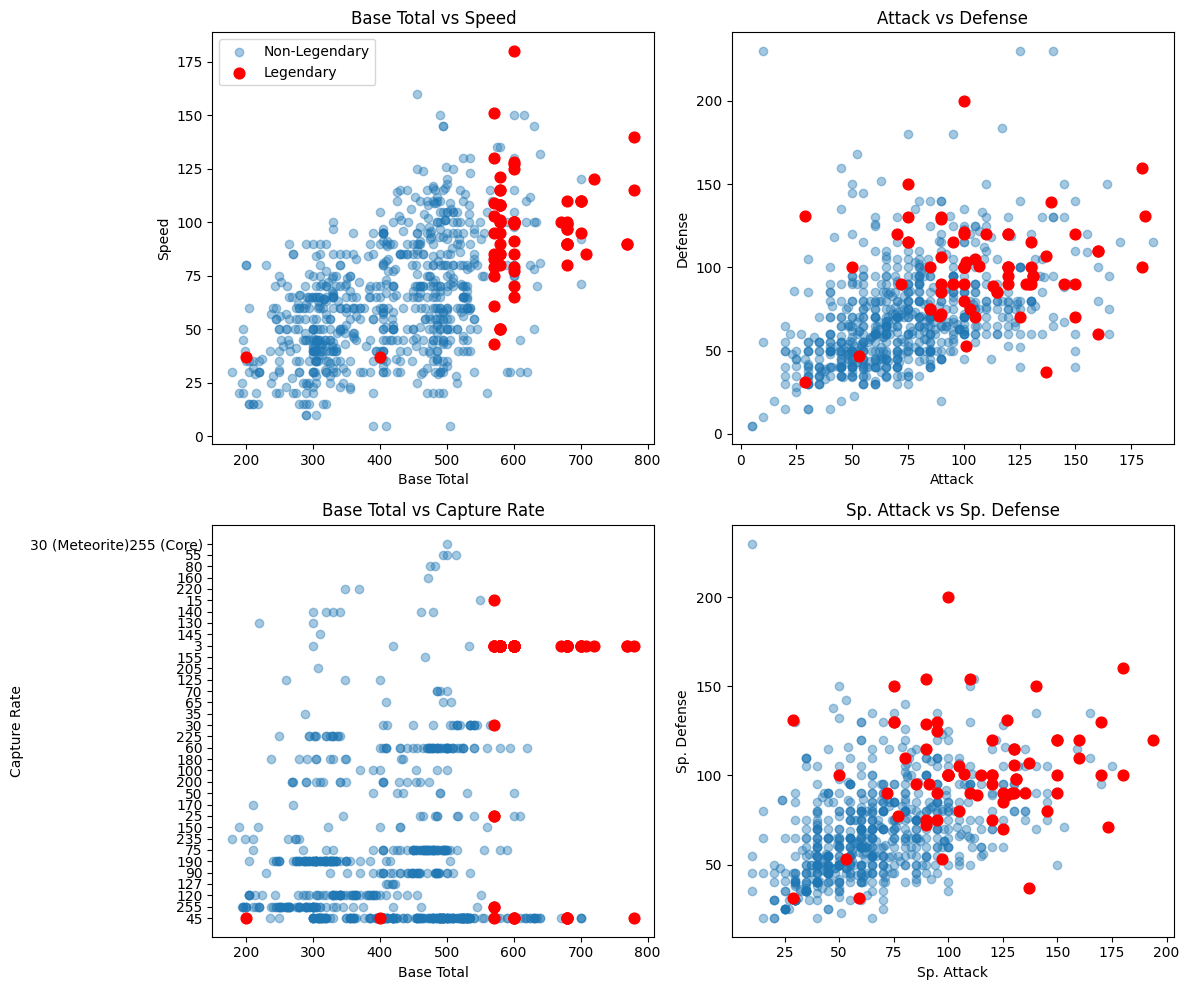

In [25]:
# Split data
legendary = df[df['is_legendary'] == 1]
non_legendary = df[df['is_legendary'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# 1. Base Total vs Speed
axes[0].scatter(non_legendary['base_total'], non_legendary['speed'], alpha=0.4, label='Non-Legendary')
axes[0].scatter(legendary['base_total'], legendary['speed'], color='red', s=60, label='Legendary')
axes[0].set_title('Base Total vs Speed')
axes[0].set_xlabel('Base Total')
axes[0].set_ylabel('Speed')
axes[0].legend()

# 2. Attack vs Defense
axes[1].scatter(non_legendary['attack'], non_legendary['defense'], alpha=0.4)
axes[1].scatter(legendary['attack'], legendary['defense'], color='red', s=60)
axes[1].set_title('Attack vs Defense')
axes[1].set_xlabel('Attack')
axes[1].set_ylabel('Defense')

# 3. Base Total vs Capture Rate
axes[2].scatter(non_legendary['base_total'], non_legendary['capture_rate'], alpha=0.4)
axes[2].scatter(legendary['base_total'], legendary['capture_rate'], color='red', s=60)
axes[2].set_title('Base Total vs Capture Rate')
axes[2].set_xlabel('Base Total')
axes[2].set_ylabel('Capture Rate')

# 4. Sp. Attack vs Sp. Defense
axes[3].scatter(non_legendary['sp_attack'], non_legendary['sp_defense'], alpha=0.4)
axes[3].scatter(legendary['sp_attack'], legendary['sp_defense'], color='red', s=60)
axes[3].set_title('Sp. Attack vs Sp. Defense')
axes[3].set_xlabel('Sp. Attack')
axes[3].set_ylabel('Sp. Defense')

plt.tight_layout()
plt.show()

In [26]:
# Cleaning

# Drop useless columns
df = df.drop(columns=[
    "abilities",
    "japanese_name",
    "name",
    "classfication"
])

# Fix data type (capture_rate is string instead of int)
df["capture_rate"] = pd.to_numeric(df["capture_rate"], errors="coerce")

# Fill type2 missing data with None, fill percentage_male, height, weight with median
df["type2"] = df["type2"].fillna("None")
df["percentage_male"] = df["percentage_male"].fillna(df["percentage_male"].median())
df["height_m"] = df["height_m"].fillna(df["height_m"].median())
df["weight_kg"] = df["weight_kg"].fillna(df["weight_kg"].median())
df["capture_rate"] = df["capture_rate"].fillna(df["capture_rate"].median())

# Encode categorical variables (type1 and type2)
df = pd.get_dummies(df, columns=["type1", "type2"], drop_first=True)

In [27]:
# Define features and target variable 
# Target: Is the pokemon legendary or not?
X = df.drop(columns=["is_legendary"])
y = df["is_legendary"]

In [28]:
# Check no missing values left and shape
# We have 801 pokemons and 69 features and no missing values left

print("Any NaNs left:", np.isnan(X).sum().sum())
print("Shape of X:", X.shape)

Any NaNs left: 0
Shape of X: (801, 69)


In [29]:
# Scale numeric features to mean=0, std=1; convert boolean features to 0/1
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
bool_cols = X.select_dtypes(include=['bool']).columns

X[bool_cols] = X[bool_cols].astype(int)

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(f"Scaled {len(numeric_cols)} numeric columns, converted {len(bool_cols)} boolean columns")
print("Shape of X:", X.shape)

Scaled 34 numeric columns, converted 35 boolean columns
Shape of X: (801, 69)


In [30]:
# Train/test split (70/30, stratified by target class)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=11, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (560, 69), Test: (241, 69)


In [31]:
# Johnson-Lindenstrauss bound
# This is only a theoretical distance-preservation bound/ worst-case theoretical guarantee, not a classification optimum
# If you want to preserve all pairwise distances between points with very small error (ε=0.1), then you may need a high dimension (5730 dimensions for 801 samples)
jl_bound = johnson_lindenstrauss_min_dim(n_samples=X.shape[0], eps=0.1)
print(f"Johnson-Lindenstrauss lower bound for eps=0.1: k >= {jl_bound} given n={X.shape[0]} samples")

Johnson-Lindenstrauss lower bound for eps=0.1: k >= 5730 given n=801 samples


In [32]:
# Class distribution in target variable 
# Majority-class baseline accuracy (~91%) for comparison 
# unbalanced classes (801 pokemons, 70 legendary → 731 non-legendary)
print(y.value_counts(normalize=True))

is_legendary
0    0.912609
1    0.087391
Name: proportion, dtype: float64


### Baseline and Random Projection Experiment

In [33]:
# Baseline model on full dimensionality
baseline_model = LinearSVC(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)
print(f"Baseline accuracy (d={X.shape[1]}): {baseline_acc:.4f}")
print(f"Baseline F1-score: {baseline_f1:.4f}")

# Random projection experiment (log-spaced dimensions)
realizations = 15
dims = make_dims(X.shape[1], n_points=15)
print(f"\nTested dimensions ({len(dims)}): {dims}")
print(f"Running {realizations} random projections per dimension...\n")

poke_results = run_rp_experiment(
    X_train, X_test, y_train, y_test, dims,
    realizations=realizations, max_iter=1000, f1_avg='binary'
)

Baseline accuracy (d=69): 0.9876
Baseline F1-score: 0.9231

Tested dimensions (14): [ 2  3  4  5  7  9 11 15 19 25 32 41 53 69]
Running 15 random projections per dimension...

  k=   2:  acc = 0.9167 +/- 0.0082  |  F1 = 0.1237 +/- 0.1789
  k=   3:  acc = 0.9151 +/- 0.0042  |  F1 = 0.0648 +/- 0.1214
  k=   4:  acc = 0.9201 +/- 0.0197  |  F1 = 0.1526 +/- 0.2416
  k=   5:  acc = 0.9261 +/- 0.0219  |  F1 = 0.2422 +/- 0.2799
  k=   7:  acc = 0.9331 +/- 0.0149  |  F1 = 0.4247 +/- 0.2243
  k=   9:  acc = 0.9358 +/- 0.0161  |  F1 = 0.4641 +/- 0.2129
  k=  11:  acc = 0.9563 +/- 0.0233  |  F1 = 0.6733 +/- 0.2085
  k=  15:  acc = 0.9635 +/- 0.0222  |  F1 = 0.7529 +/- 0.1658
  k=  19:  acc = 0.9698 +/- 0.0166  |  F1 = 0.8058 +/- 0.1280
  k=  25:  acc = 0.9743 +/- 0.0108  |  F1 = 0.8438 +/- 0.0684
  k=  32:  acc = 0.9828 +/- 0.0050  |  F1 = 0.8964 +/- 0.0320
  k=  41:  acc = 0.9864 +/- 0.0039  |  F1 = 0.9180 +/- 0.0238
  k=  53:  acc = 0.9881 +/- 0.0048  |  F1 = 0.9281 +/- 0.0294
  k=  69:  acc = 0

### Results

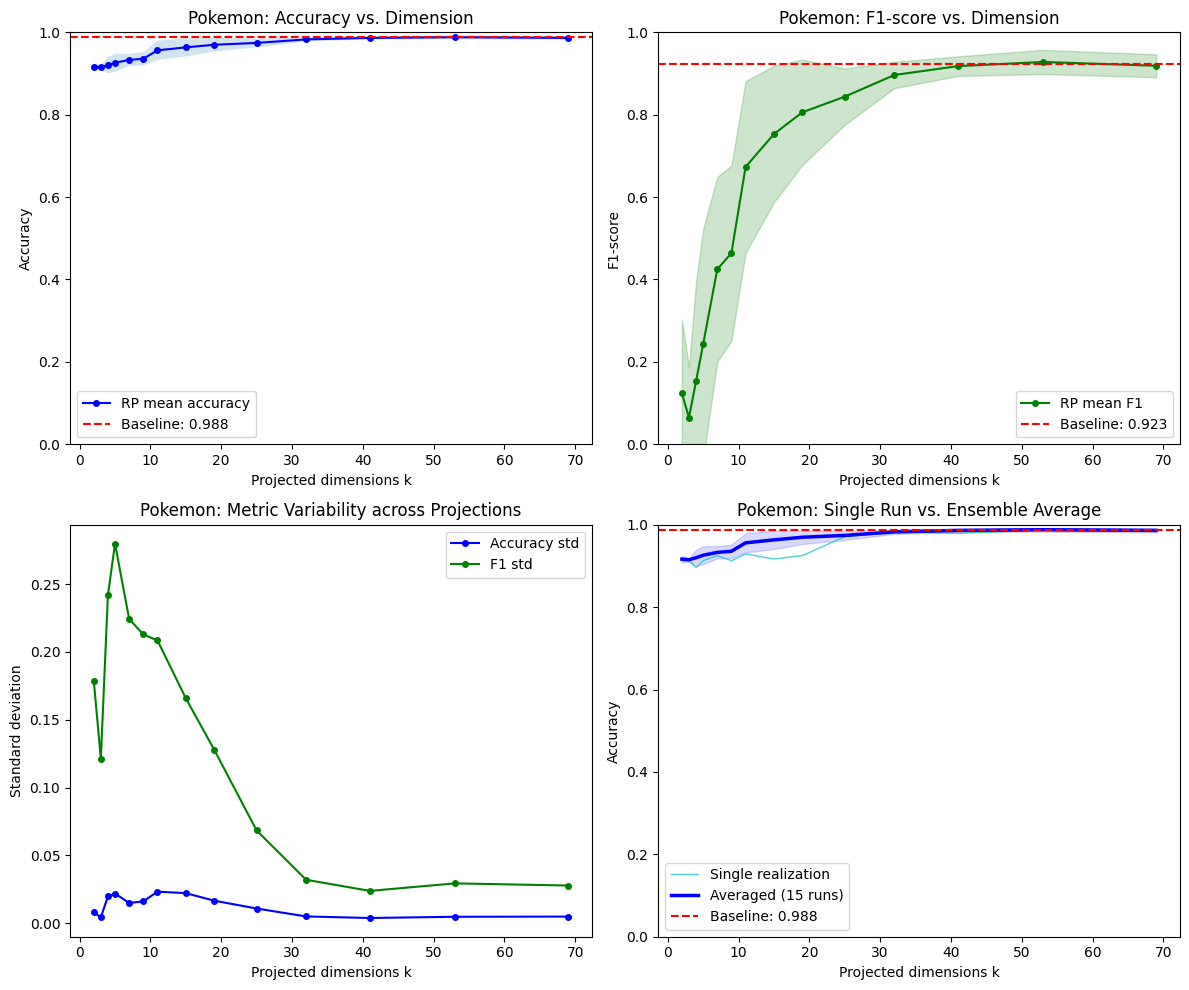

In [34]:
plot_rp_results(dims, poke_results, baseline_acc, baseline_f1,
                'Pokemon', realizations)

## 2. Fashion Dataset

**Dataset:**
- **Fashion-MNIST** (Zalando): 60,000 grayscale images (28×28) of clothing items, 10 classes

The dataset lives in 784-dimensional Euclidean space, making it well-suited for random projection analysis.

### Load and Explore

We load the Fashion-MNIST dataset from CSV. Each row is one image: the first column is the class label, the remaining 784 columns are pixel values (28x28 grayscale). We subsample to keep computation time reasonable.

In [35]:
# --- Fashion-MNIST ---
fashion_df = pd.read_csv("fashion-mnist_train.csv")
# Subsample to 5,000 for faster computation
fashion_df = fashion_df.sample(n=5000, random_state=42)
fashion_data = fashion_df.iloc[:, 1:].values   # 784 pixel columns
fashion_target = fashion_df.iloc[:, 0].values   # label column

fashion_labels = {0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress",
                  4: "Coat", 5: "Sandal", 6: "Shirt", 7: "Sneaker",
                  8: "Bag", 9: "Ankle boot"}

print(f"Fashion-MNIST: {fashion_data.shape[0]} samples, {fashion_data.shape[1]} features, "
      f"{len(np.unique(fashion_target))} classes")

Fashion-MNIST: 5000 samples, 784 features, 10 classes


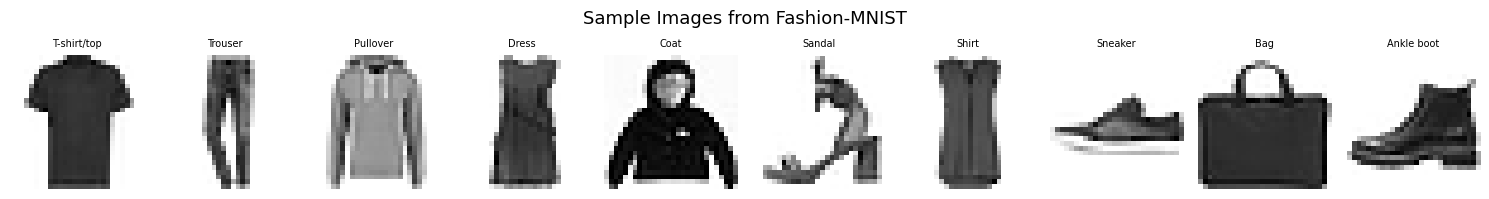

In [36]:
# Visualize sample images from the dataset
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

# Fashion-MNIST samples (one per class)
for i in range(10):
    idx = np.where(fashion_target == i)[0][0]
    axes[i].imshow(fashion_data[idx].reshape(28, 28), cmap=plt.cm.gray_r, interpolation='nearest')
    axes[i].set_title(fashion_labels[i], fontsize=7)
    axes[i].axis('off')

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=13)
plt.tight_layout()
plt.show()

### Johnson-Lindenstrauss Bound

The JL lemma states that $n$ points in high-dimensional space can be projected into $k$ dimensions while approximately preserving pairwise distances, provided:

$$k \geq \frac{4 \ln(n)}{\varepsilon^2 / 2 - \varepsilon^3 / 3}$$

where $\varepsilon$ controls the distortion tolerance. This bound is very conservative; in practice, good classification accuracy can be achieved with far fewer dimensions.

In [37]:
eps = 0.1
n_fashion = fashion_data.shape[0]

jl_fashion = johnson_lindenstrauss_min_dim(n_fashion, eps=eps)

print(f"JL minimum dimensions (eps={eps}):")
print(f"  Fashion-MNIST (n={n_fashion}): k >= {jl_fashion}")
print(f"\nOriginal dimensionality: d = 784")
print(f"The JL bound exceeds d=784, so the lemma does not guarantee preservation at eps=0.1.")
print(f"However, JL is a worst-case bound. Classification may still work well at much lower k.")

JL minimum dimensions (eps=0.1):
  Fashion-MNIST (n=5000): k >= 7300

Original dimensionality: d = 784
The JL bound exceeds d=784, so the lemma does not guarantee preservation at eps=0.1.
However, JL is a worst-case bound. Classification may still work well at much lower k.


### Train/Test Split and Baseline

We split 70/30, then train a LinearSVC on the full 784-dimensional data to establish a baseline accuracy and F1-score.

In [38]:
# Train/test split (70/30)
fash_trainX, fash_testX, fash_trainY, fash_testY = train_test_split(
    fashion_data, fashion_target, test_size=0.3, random_state=42
)

# Baseline model on full dimensionality
baseline_model = LinearSVC(max_iter=2000, random_state=42)
baseline_model.fit(fash_trainX, fash_trainY)
baseline_pred = baseline_model.predict(fash_testX)

baseline_fashion_acc = accuracy_score(fash_testY, baseline_pred)
baseline_fashion_f1 = f1_score(fash_testY, baseline_pred, average='macro', zero_division=0)
print(f"Baseline accuracy (d={fashion_data.shape[1]}): {baseline_fashion_acc:.4f}")
print(f"Baseline macro F1-score: {baseline_fashion_f1:.4f}")

Baseline accuracy (d=784): 0.7320
Baseline macro F1-score: 0.7410


### Random Projection Experiment

For each target dimensionality $k$ we generate a sparse random projection matrix, project both train and test data, train a LinearSVC, and evaluate accuracy and F1-score. We repeat this over multiple realizations and average the results.

Dimensions are log-spaced so that we test more projections at low $k$ (where accuracy changes rapidly) and fewer at high $k$ (where it plateaus), reducing total computation time.

In [39]:
# Random projection experiment (log-spaced dimensions)
realizations = 15
dims_fashion = make_dims(fashion_data.shape[1], n_points=20)
print(f"Tested dimensions ({len(dims_fashion)}): {dims_fashion}")
print(f"Running {realizations} random projections per dimension...\n")

fashion_results = run_rp_experiment(
    fash_trainX, fash_testX, fash_trainY, fash_testY, dims_fashion,
    realizations=realizations, max_iter=2000, f1_avg='macro'
)

Tested dimensions (19): [  2   3   5   7   9  13  18  24  33  46  63  86 118 162 223 305 418 572
 784]
Running 15 random projections per dimension...

  k=   2:  acc = 0.2735 +/- 0.0298  |  F1 = 0.1920 +/- 0.0310
  k=   3:  acc = 0.3569 +/- 0.0262  |  F1 = 0.2939 +/- 0.0274
  k=   5:  acc = 0.4596 +/- 0.0327  |  F1 = 0.4204 +/- 0.0384
  k=   7:  acc = 0.5305 +/- 0.0289  |  F1 = 0.5008 +/- 0.0334
  k=   9:  acc = 0.5735 +/- 0.0196  |  F1 = 0.5520 +/- 0.0210
  k=  13:  acc = 0.6330 +/- 0.0194  |  F1 = 0.6166 +/- 0.0239
  k=  18:  acc = 0.6780 +/- 0.0173  |  F1 = 0.6658 +/- 0.0192
  k=  24:  acc = 0.7103 +/- 0.0114  |  F1 = 0.7011 +/- 0.0120
  k=  33:  acc = 0.7376 +/- 0.0104  |  F1 = 0.7318 +/- 0.0125
  k=  46:  acc = 0.7631 +/- 0.0068  |  F1 = 0.7611 +/- 0.0070
  k=  63:  acc = 0.7772 +/- 0.0067  |  F1 = 0.7759 +/- 0.0071
  k=  86:  acc = 0.7866 +/- 0.0051  |  F1 = 0.7864 +/- 0.0050
  k= 118:  acc = 0.7772 +/- 0.0076  |  F1 = 0.7774 +/- 0.0077
  k= 162:  acc = 0.7619 +/- 0.0111  |  F1 =

### Results

The plots show the averaged accuracy and F1-score (solid lines) with shaded $\pm 1\sigma$ bands indicating variability across random projections. The red dashed line is the baseline on the full 784-dimensional data. The bottom-right panel demonstrates why ensemble averaging produces a smoother, more reliable curve than a single random projection.

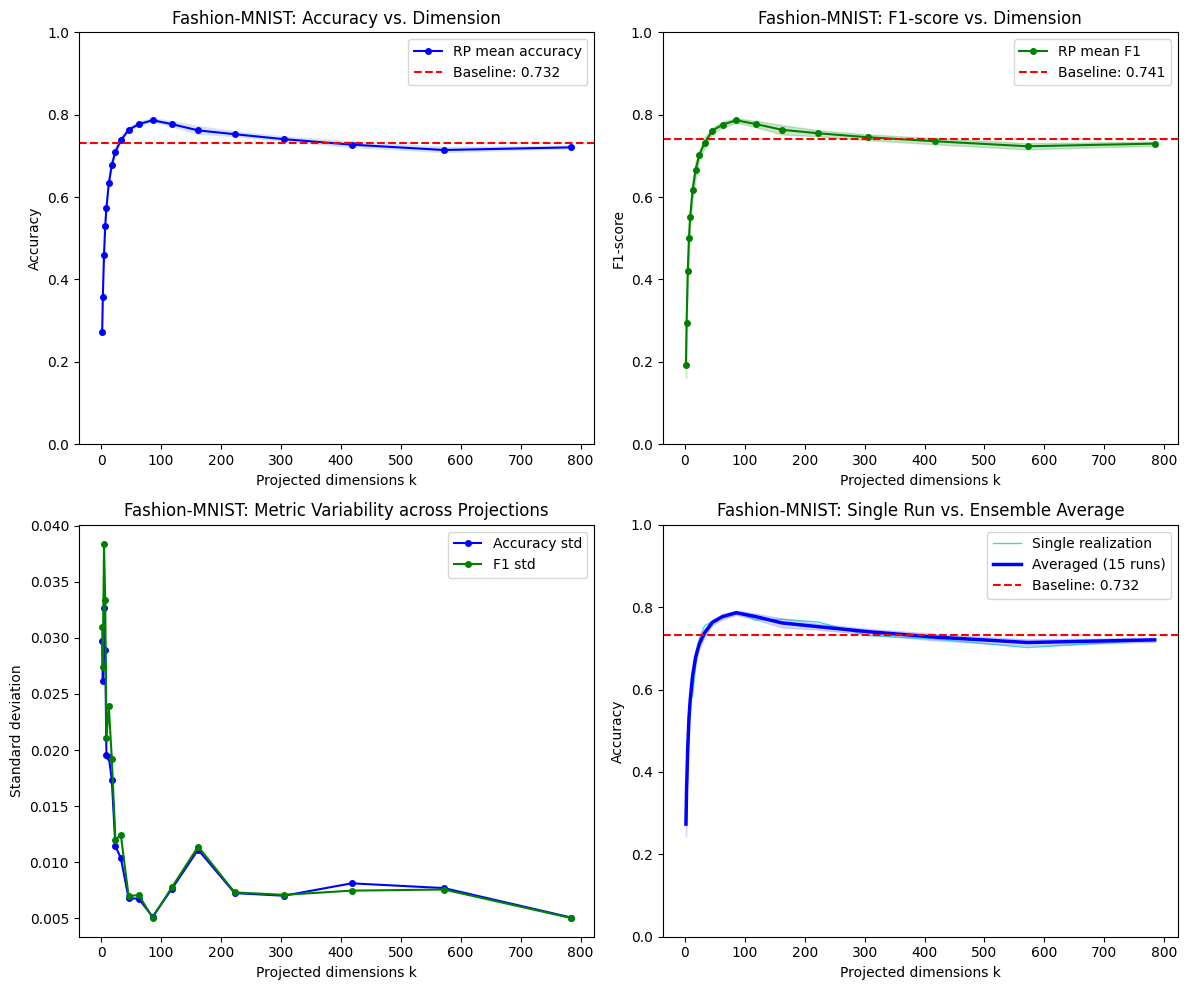

In [40]:
plot_rp_results(dims_fashion, fashion_results, baseline_fashion_acc, baseline_fashion_f1,
                'Fashion-MNIST', realizations)

## Take-Home Message

**Key findings from this analysis:**

1. **Random projections preserve classification accuracy remarkably well.** Even though the Johnson-Lindenstrauss bound suggests we need more dimensions than the original 784, in practice Fashion-MNIST achieves near-baseline accuracy with far fewer dimensions (typically around 100-200 projected dimensions out of 784). Same counts for the Pokémon dataset where performance stabilized at around 25-30 dimensions of 69. Beyond this point, additional dimensions provide negligible improvements, indicating redundancy in the original feature space.

2. **Ensembling is essential.** A single random projection produces a noisy, zig-zag accuracy curve because each random matrix preserves different aspects of the data structure. Averaging over multiple realizations yields a smooth, monotonically increasing curve that clearly shows the relationship between dimensionality and accuracy.

3. **Image data in Euclidean space is well-suited for random projections.** Fashion-MNIST is an image dataset where Euclidean distance is a meaningful similarity measure. This is why random projections work well here: the projection approximately preserves the pairwise distances that the classifier relies on.

4. **Diminishing returns at higher dimensions.** The accuracy curve shows rapid improvement at low dimensions and then plateaus as $k$ approaches the original dimensionality. This suggests that much of the discriminative information in these 784-dimensional images lives in a much lower-dimensional subspace, and random projections are effective at capturing it.

5. **Practical implication:** Random projections offer a simple, data-independent method for dimensionality reduction that can dramatically reduce storage and computation costs while maintaining classification performance. Unlike PCA, they require no eigenvalue computation and can be applied to streaming data.